# Deep Learning — Digit Recognition with CNN
## Notebook 1: Architecture, Training & Evaluation

**Business Problem:** Automate the reading of handwritten digits in physical documents — bank checks, utility meters, paper forms — eliminating manual data entry and its associated errors.

**Dataset:** MNIST — 70,000 handwritten digit images (28×28 px, grayscale)  
**Approach:** Convolutional Neural Network (CNN) trained end-to-end with PyTorch

---
**Sections:**
1. Setup & Device Configuration
2. Data Loading & Augmentation
3. Dataset Exploration
4. CNN Architecture
5. Training Loop
6. Training Curves
7. Test Evaluation
8. Save Model

## 1. Setup & Device Configuration

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')
if device.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

PyTorch version : 2.8.0+cpu
Device          : cpu


## 2. Data Loading & Augmentation

**Training augmentations:**  
Small random rotations and translations simulate real-world handwriting variability — digits are rarely perfectly centered or upright in scanned documents.

In [2]:
# MNIST mean and std (precomputed)
MEAN, STD = 0.1307, 0.3081

train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,))
])

DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

train_dataset = torchvision.datasets.MNIST(DATA_DIR, train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.MNIST(DATA_DIR, train=False, download=True, transform=test_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training samples  : {len(train_dataset):,}')
print(f'Test samples      : {len(test_dataset):,}')
print(f'Training batches  : {len(train_loader):,}')
print(f'Image shape       : {train_dataset[0][0].shape}')

Training samples  : 60,000
Test samples      : 10,000
Training batches  : 938
Image shape       : torch.Size([1, 28, 28])


## 3. Dataset Exploration

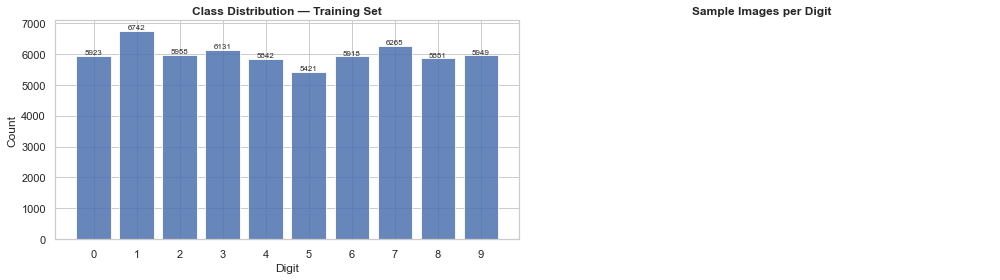

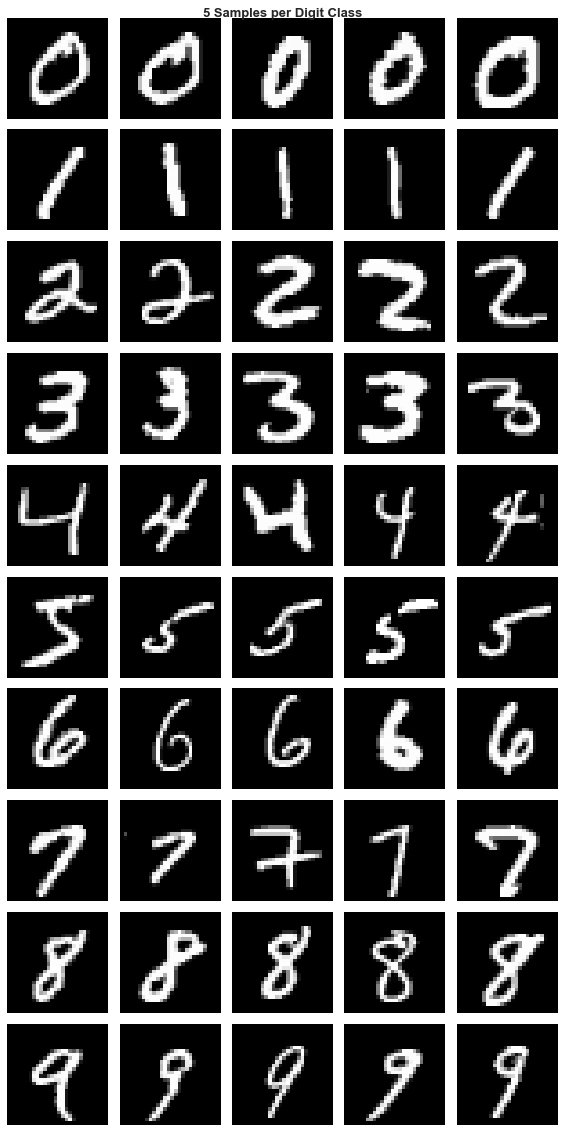

In [3]:
# Class distribution
labels = train_dataset.targets.numpy()
counts = np.bincount(labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(10), counts, color='#4C72B0', alpha=0.85)
axes[0].set_xticks(range(10))
axes[0].set_title('Class Distribution — Training Set', fontweight='bold')
axes[0].set_xlabel('Digit')
axes[0].set_ylabel('Count')
for i, c in enumerate(counts):
    axes[0].text(i, c + 50, str(c), ha='center', fontsize=8)

# Sample images (no augmentation for visualization)
raw_dataset = torchvision.datasets.MNIST(DATA_DIR, train=True, download=False,
                                          transform=transforms.ToTensor())
axes[1].axis('off')
axes[1].set_title('Sample Images per Digit', fontweight='bold')
plt.tight_layout()
plt.show()

# Grid: 2 samples per digit
fig, axes = plt.subplots(10, 5, figsize=(8, 16))
for digit in range(10):
    idx = (raw_dataset.targets == digit).nonzero(as_tuple=True)[0][:5]
    for col, i in enumerate(idx):
        axes[digit, col].imshow(raw_dataset[i][0].squeeze(), cmap='gray')
        axes[digit, col].axis('off')
        if col == 0:
            axes[digit, col].set_ylabel(str(digit), fontsize=12, rotation=0, labelpad=15)

fig.suptitle('5 Samples per Digit Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. CNN Architecture

```
Input (1×28×28)
  │
  ├── Conv Block 1: Conv2d(1→32) + BN + ReLU + MaxPool → 32×14×14
  ├── Conv Block 2: Conv2d(32→64) + BN + ReLU + MaxPool → 64×7×7
  ├── Conv Block 3: Conv2d(64→128) + BN + ReLU + MaxPool → 128×3×3
  │
  └── Classifier: Flatten → Linear(1152→256) → ReLU → Dropout(0.5) → Linear(256→10)
```

**Design decisions:**
- **BatchNorm** after each conv: stabilizes training, allows higher learning rates
- **MaxPool** halves spatial dimensions at each stage: reduces computation while preserving dominant features
- **Dropout(0.5)** in the classifier: prevents overfitting on the fully-connected layers

In [4]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)          # 28x28 → 14x14
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)          # 14x14 → 7x7
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)          # 7x7 → 3x3
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return self.classifier(x)


model = DigitCNN().to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

DigitCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features

## 5. Training Loop

In [5]:
EPOCHS = 15
LR     = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
# Reduce LR by 50% if validation loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

print(f'Training on {device} for {EPOCHS} epochs...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Test Loss":>9} | {"Test Acc":>8}')
print('-' * 55)

best_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = eval_epoch(model, test_loader, criterion)
    scheduler.step(te_loss)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2%} | {te_loss:>9.4f} | {te_acc:>7.2%}')

print(f'\nBest test accuracy: {best_acc:.2%}')

Training on cpu for 15 epochs...

 Epoch | Train Loss | Train Acc | Test Loss | Test Acc
-------------------------------------------------------
     1 |     0.2521 |   92.22% |    0.0482 |  98.53%
     2 |     0.1000 |   97.08% |    0.0274 |  99.17%
     3 |     0.0797 |   97.71% |    0.0297 |  98.93%
     4 |     0.0680 |   97.98% |    0.0219 |  99.29%
     5 |     0.0583 |   98.20% |    0.0212 |  99.29%
     6 |     0.0535 |   98.38% |    0.0262 |  99.19%
     7 |     0.0504 |   98.47% |    0.0217 |  99.25%
     8 |     0.0457 |   98.68% |    0.0207 |  99.34%
     9 |     0.0439 |   98.75% |    0.0185 |  99.38%
    10 |     0.0408 |   98.80% |    0.0168 |  99.49%
    11 |     0.0368 |   98.92% |    0.0195 |  99.43%
    12 |     0.0349 |   98.96% |    0.0139 |  99.50%
    13 |     0.0329 |   99.01% |    0.0158 |  99.48%
    14 |     0.0329 |   99.02% |    0.0144 |  99.51%
    15 |     0.0311 |   99.09% |    0.0173 |  99.45%

Best test accuracy: 99.51%


## 6. Training Curves

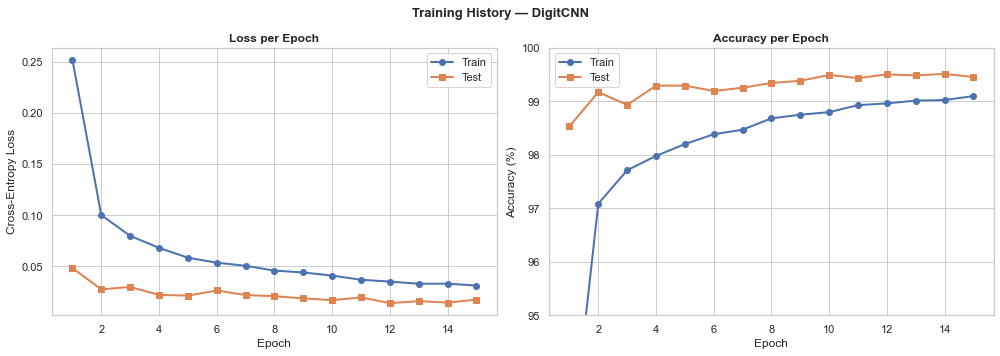

In [6]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, history['train_loss'], 'o-', color='#4C72B0', linewidth=2, label='Train')
axes[0].plot(epochs, history['test_loss'],  's-', color='#DD8452', linewidth=2, label='Test')
axes[0].set_title('Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()

# Accuracy
axes[1].plot(epochs, [a * 100 for a in history['train_acc']], 'o-', color='#4C72B0', linewidth=2, label='Train')
axes[1].plot(epochs, [a * 100 for a in history['test_acc']],  's-', color='#DD8452', linewidth=2, label='Test')
axes[1].set_title('Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(95, 100)
axes[1].legend()

plt.suptitle('Training History — DigitCNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Test Evaluation

In [7]:
# Load best checkpoint
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

# Save predictions for notebook 02
np.save('data/test_preds.npy',  all_preds)
np.save('data/test_labels.npy', all_labels)
np.save('data/test_probs.npy',  all_probs)
print('Saved predictions to data/')

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      1.00      1010
           4       1.00      0.99      1.00       982
           5       0.99      0.99      0.99       892
           6       0.99      1.00      1.00       958
           7       1.00      0.99      0.99      1028
           8       1.00      0.99      1.00       974
           9       0.99      1.00      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

Saved predictions to data/


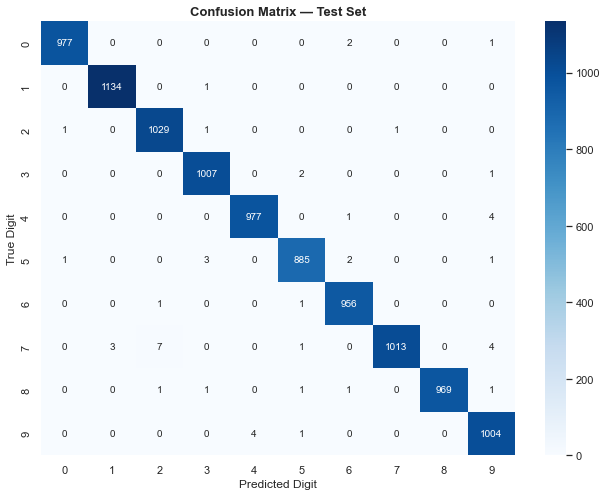

Test Accuracy : 99.51%
Total errors  : 49 out of 10,000 samples


In [8]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(10), yticklabels=range(10))
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Digit')
ax.set_ylabel('True Digit')
plt.tight_layout()
plt.show()

accuracy = (all_preds == all_labels).mean()
errors   = (all_preds != all_labels).sum()
print(f'Test Accuracy : {accuracy:.2%}')
print(f'Total errors  : {errors} out of {len(all_labels):,} samples')

## 8. Save Model

In [9]:
# Save full model info for reproducibility
checkpoint = {
    'model_state_dict': model.state_dict(),
    'architecture': 'DigitCNN',
    'test_accuracy': float(accuracy),
    'epochs_trained': EPOCHS,
    'optimizer': 'Adam',
    'lr': LR
}
torch.save(checkpoint, 'digit_cnn_checkpoint.pth')
print(f'Model saved: digit_cnn_checkpoint.pth')
print(f'Final test accuracy: {accuracy:.2%}')

Model saved: digit_cnn_checkpoint.pth
Final test accuracy: 99.51%
